In [ ]:
"""
Soares, Eduardo, Angelov, Plamen, Biaso, Sarah, Higa Froes, Michele, and Kanda Abe, Daniel. "SARS-CoV-2 CT-scan dataset: A large dataset of real patients CT scans for SARS-CoV-2 identification." medRxiv (2020). doi: https://doi.org/10.1101/2020.04.24.20078584.
Angelov, P., & Soares, E. (2020). Towards explainable deep neural networks (xDNN). Neural Networks, 130, 185-194.

The dataset used is "SARS-CoV-2 CT-scan dataset: A large dataset of real patients CT scans for SARS-CoV-2 identification."

Licensed under CC BY-NC-SA 4.0.

Link to the Kaggle dataset: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset
"""

'\nSoares, Eduardo, Angelov, Plamen, Biaso, Sarah, Higa Froes, Michele, and Kanda Abe, Daniel. "SARS-CoV-2 CT-scan dataset: A large dataset of real patients CT scans for SARS-CoV-2 identification." medRxiv (2020). doi: https://doi.org/10.1101/2020.04.24.20078584.\nAngelov, P., & Soares, E. (2020). Towards explainable deep neural networks (xDNN). Neural Networks, 130, 185-194.\n\nThe dataset used is "SARS-CoV-2 CT-scan dataset: A large dataset of real patients CT scans for SARS-CoV-2 identification."\n\n\n\nLicensed under CC BY-NC-SA 4.0.\n\nLink to the Kaggle dataset: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset\n'

In [ ]:
import kagglehub
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import IPython.display as display
import ipywidgets.widgets as widgets
import numpy as np

train_path = kagglehub.dataset_download("plameneduardo/sarscov2-ctscan-dataset")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation"
)

100%|██████████| 230M/230M [00:01<00:00, 133MB/s] 

Extracting files...


Found 2481 files belonging to 2 classes.
Using 1985 files for training.
Found 2481 files belonging to 2 classes.
Using 496 files for validation.


Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)


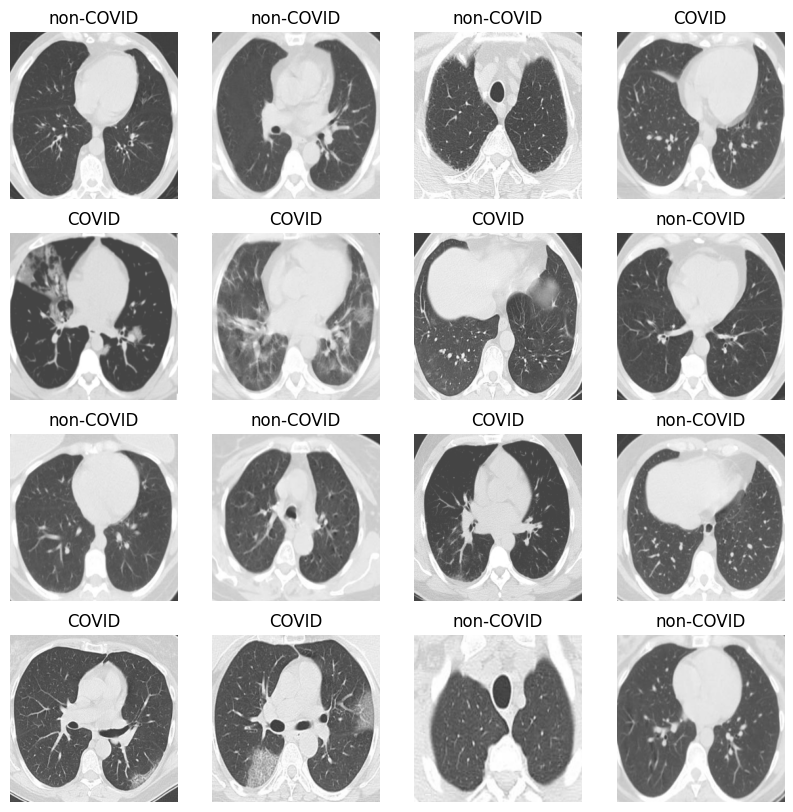

In [ ]:
classes = train_ds.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  print(f"Images batch shape: {images.shape}")
  print(f"Labels batch shape: {labels.shape}")
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(classes[labels[i]])
    plt.axis("off")

In [ ]:
SCALE = 1/127.5

model = tf.keras.Sequential(layers=[
    tf.keras.layers.Rescaling(SCALE, offset=-1),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

In [ ]:
optimizer = tf.keras.optimizers.AdamW(gradient_accumulation_steps=4)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        keras.metrics.BinaryAccuracy(),
    ]
)

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 345ms/step - binary_accuracy: 0.6524 - loss: 0.5988 - val_binary_accuracy: 0.7601 - val_loss: 0.5135
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - binary_accuracy: 0.7970 - loss: 0.4533 - val_binary_accuracy: 0.8226 - val_loss: 0.4175
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - binary_accuracy: 0.8620 - loss: 0.3480 - val_binary_accuracy: 0.8327 - val_loss: 0.4044
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - binary_accuracy: 0.7028 - loss: 0.6396 - val_binary_accuracy: 0.7056 - val_loss: 0.5366
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - binary_accuracy: 0.8322 - loss: 0.4010 - val_binary_accuracy: 0.8266 - val_loss: 0.3961
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - binary_accuracy: 0.8650 - loss: 0.3324 - val_binary_accuracy: 0.8387 - val_loss: 0.3781
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - binary_accuracy: 0.8836 - loss: 0.2849 - val_binary_accuracy: 0.8488 - val_loss: 0.3345

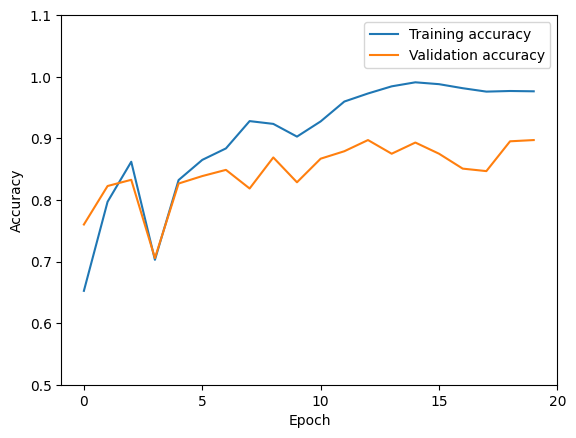

In [ ]:
train_binary_accuracy = model.history.history["binary_accuracy"]
val_binary_accuracy = model.history.history["val_binary_accuracy"]

plt.plot(train_binary_accuracy, label="Training accuracy")
plt.plot(val_binary_accuracy, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0, 25, 5))
plt.yticks(np.arange(0.5, 1.1, 0.1))
plt.legend()


FileUpload(value={}, accept='.png', description='Upload', multiple=True, style=ButtonStyle(button_color='light…

Dropdown(description='Are these the correct images?', options=('Yes', 'No'), style=DescriptionStyle(descriptio…

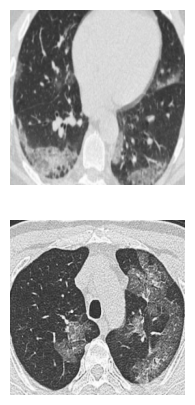

No covid.
No covid.
No covid.
No covid.


In [ ]:
uploader = widgets.FileUpload(accept=".png", multiple=True, style={
    "button_color": "lightblue",
    "text_color": "black"
})


images = []
def load_images():
  for file in uploader.value.keys():
    image = tf.image.decode_png(uploader.value[file]["content"])
    image = tf.image.resize(image, (256, 256))
    images.append(image)

def show_images():
  plt.figure(figsize=(5, 5))
  for img in images:
    for i in range(len(images)):
      ax = plt.subplot(len(images), 1, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))
      plt.axis("off")

confirm_dropdown = widgets.Dropdown(
  options=["Yes", "No"],
  description="Are these the correct images?",
  value=None,
  style={
    "description_width": "180px"
  }
)

def classify_images(images):
  for image in images:
    image = np.expand_dims(image, axis=0)
    if model(image) < 0.5:
      print("No covid.")
    elif model(image) > 0.5:
      print("Covid.")

def on_change(change):
  if change["type"] == "change" and change["name"] == "value" and change["new"] == "Yes":
    classify_images(images)

def on_upload(change):
  confirm_dropdown.observe(on_change, names="value", type="change")
  display.display(confirm_dropdown)
  load_images()
  show_images()

uploader.observe(on_upload, names="value", type="change")
display.display(uploader)